# Rain Field Simulation Demo

This notebook creates a simple rain field using moving Gaussian rain cells. The field is represented as `R[t, y, x]` in units of mm/hour.

In [1]:
import matplotlib.pyplot as plt

from rain_field_simulation import simulate_gaussian_rain_field
from rain_field_visualization import animate_rain_field, display_rain_animation

## Create a Simulation

The simulator returns a `RainField` object. Its main data array is `values_mm_h`, with shape `[time, y, x]`.

In [2]:
rain = simulate_gaussian_rain_field(
    domain_width_km=20.0,
    domain_height_km=20.0,
    dx_km=0.25,
    dy_km=0.25,
    duration_h=1.0,
    dt_h=1.0 / 60.0,
    num_random_cells=5,
    wind_velocity_km_h=(8.0, 3.0),
    decay_h_inv=0.05,
    seed=42,
)

rain.values_mm_h.shape

(61, 81, 81)

## Display One Frame

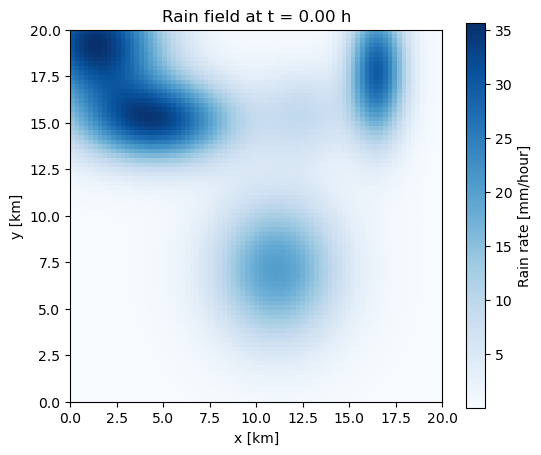

In [3]:
frame_index = 0

plt.figure(figsize=(6, 5))
plt.imshow(
    rain.at_grid(frame_index),
    origin="lower",
    extent=[rain.x_km.min(), rain.x_km.max(), rain.y_km.min(), rain.y_km.max()],
    cmap="Blues",
)
plt.colorbar(label="Rain rate [mm/hour]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"Rain field at t = {rain.t_h[frame_index]:.2f} h")
plt.show()

## Play the Simulation

In [4]:
animation = animate_rain_field(rain, interval_ms=120)
display_rain_animation(animation)

## Sample R(x, y, t)

This is the kind of value a link-measurement module will later sample along a path.

In [5]:
rain.sample_nearest(x_km=10.0, y_km=10.0, t_h=0.5)

2.119235000946041